# Tutorial 09 — Barium titanate: bulk perovskite

The waw-native reimagining of Wannier90 tutorial 9. Cubic perovskite **BaTiO$_3$** is the first multi-species system in the series, and the first case where the isolated manifold is picked with `exclude_bands` alone (no disentanglement window at all): with PseudoDojo's electron counts (Ba 10 + Ti 12 + 3$\times$O 6 = 40 valence electrons, exactly matching the classic tutorial's ultrasoft-pseudo total) the crystal has **20 occupied bands**, and the top 9 (O 2$p$ character) are excluded-in directly — `nb == nw == 9`, so `wannierize()` runs with no outer/frozen window at all, same as the isolated-band notebooks 01/05/07.

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

# locate the repo root (the folder containing the `waw` package), so the
# notebook runs from anywhere
HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not w90tutorial-specific
NCORES = 16
waw.set_num_threads(NCORES)                  # use many cores for waw's batched linear algebra
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. Structure and converged DFT
Cubic perovskite, $a = 7.44266$ bohr, Ba at the cube corner, Ti body-centred, 3 O face-centred. 22 bands (20 occupied + a 2-band Davidson buffer); `exclude_bands` drops the 11 lowest (Ba/Ti semicore + O 2$s$) and the 2 buffer bands, keeping bands 12-20 = the O 2$p$ manifold.

In [2]:
from ase import Atoms

a = 7.44266 * BOHR_TO_ANG
frac = [[0, 0, 0], [0.5, 0.5, 0.5], [0, 0.5, 0.5], [0.5, 0.5, 0], [0.5, 0, 0.5]]
atoms = Atoms('BaTiO3', scaled_positions=frac,
              cell=[[a, 0, 0], [0, a, 0], [0, 0, a]], pbc=True)
MP_GRID = (4, 4, 4)
WORK = HERE / 'runs' / 'batio3'

ov = qe.generate_overlaps(
    atoms, MP_GRID, WORK, 'batio3',
    ecutwfc=60, scf_kpts=(8, 8, 8), nbnd=22, num_wann=9,
    exclude_bands=list(range(1, 12)) + [21, 22],
    pseudopotentials={'Ba': 'Ba.upf', 'Ti': 'Ti.upf', 'O': 'O.upf'},
    pseudo_dir=PSEUDO_DIR, ncores=NCORES,
    rerun_scf=False,          # reuse a completed SCF in runs/batio3/ if present
)
print('overlap shapes:', {k: np.shape(v) for k, v in ov.items()
                          if k in ('mmn', 'amn', 'eig')})

overlap shapes: {'mmn': (64, 6, 9, 9), 'amn': (64, 9, 9), 'eig': (64, 9)}


### 2. Wannierise (waw, ASE-native)
9 isolated O $2p$ bands -> 9 MLWFs, no disentanglement.

In [3]:
result = wannierize(
    atoms, MP_GRID, ov['kpts'],
    mmn=ov['mmn'], amn=ov['amn'], eig=ov['eig'],
    nnkpts=ov['nnkpts'], g_vectors=ov['g_vectors'],
    nw=9, n_restarts=3, n_iter=6000, verbose=False,
)
omega = result.omega_final * BOHR_TO_ANG**2
spreads = result.spreads_bohr2 * BOHR_TO_ANG**2
print(f'Omega_total = {omega:.4f} Ang^2   (Wannier90 tutorial09: 12.7833)')
print('per-WF spreads (Ang^2):', spreads.round(3))

Omega_total = 12.7672 Ang^2   (Wannier90 tutorial09: 12.7833)
per-WF spreads (Ang^2): [1.171 1.17  1.171 1.542 1.543 1.542 1.543 1.543 1.543]


The spreads split into 3+6 (rather than 3 equivalent triples of 3): the two crystallographically distinct oxygen sites (the one bonded to two Ti neighbours along the cell edge vs. the two related by the cubic symmetry) don't give 9 identical orbitals, matching Wannier90's own `Omega_D = 0` (a perfectly diagonal, already-optimal gauge for this isolated case) and near-exact $\Omega_I$ agreement.

### 3. Interpolated band structure
ASE's standard cubic path: the 9-band Wannier model reproduces the isolated O $2p$ valence manifold exactly (no frozen-window shading needed here — the whole manifold is exact by construction).

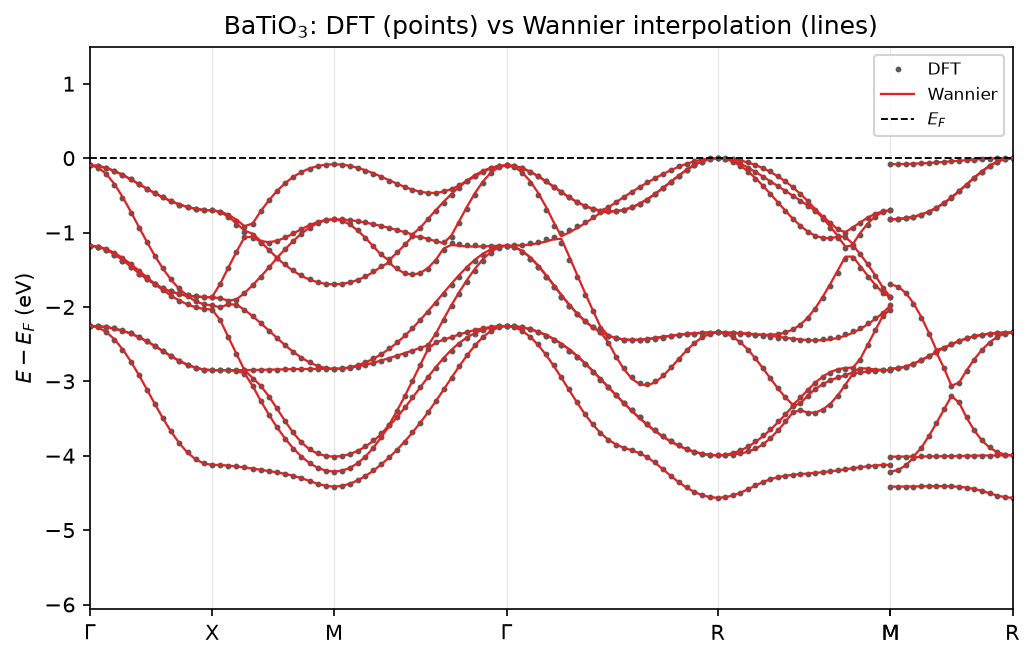

on the Wannier mesh, inside the frozen window: max 0.000 meV, rms 0.000 meV over 576 states


In [4]:
from waw.interfaces.ase.structure import band_path
from waw.core.hamiltonian import interpolate_bands
from waw.interfaces.quantum_espresso import bands_along_path
from waw.analysis.bands import mesh_fidelity
from waw.vis import plot_wannierization_windows

E_F = ov['fermi_energy']
bp = band_path(atoms, npoints=120)
xcoords, xspecial, labels = bp.get_linear_kpoint_axis()
bands = interpolate_bands(result.hr, bp.kpts) * HARTREE_TO_EV
try:
    dft_bands = bands_along_path(WORK, 'batio3', bp.kpts, ncores=NCORES)
except FileNotFoundError as exc:      # charge density not kept in this run dir
    dft_bands = np.full_like(bands, np.nan)
    print(exc)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
plot_wannierization_windows(
    ax, xcoords, dft_bands, bands,
    outer_window=None, frozen_window=None, fermi_energy=E_F,
    xticks=xspecial, xticklabels=[l.replace('G', r'$\Gamma$') for l in labels])
ax.set_title('BaTiO$_3$: DFT (points) vs Wannier interpolation (lines)')
plt.tight_layout(); plt.show()

fid = mesh_fidelity(result.hr, ov['kpts'], ov['eig'],
                    window=None, fermi_ev=E_F)
print(f"on the Wannier mesh, inside the frozen window: max {fid['max']:.3f} meV, "
      f"rms {fid['rms']:.3f} meV over {fid['n_states']} states")


**Takeaway.** A multi-species crystal needs no new machinery — `generate_overlaps`/`wannierize` already handle mixed atomic species and a purely `exclude_bands`-selected isolated manifold (no window at all) exactly like the single-species isolated-band notebooks.